# <font color="red"> **3.3 Análisis de extremos**

Los **eventos extremos** se definen como condiciones poco frecuentes dentro de la variabilidad de una variable, pero su identificación depende del enfoque utilizado y del contexto de estudio. En la clase pasada definimos una manera de analizar extremos; esto mediante las anomalías estandarizadas. Además del `Z-score`, las extremos pueden caracterizarse mediante `percentiles altos`, `umbrales físicos` (valores críticos con impacto directo), `rangos intercuartiles`, etc. Por ello, **no existe una única forma de definir extremos, sino que en muchas ocasiones es necesario combinar distintas métricas para capturar tanto su rareza estadística como su relevancia física**.

En esta clase nos enfocaremos en identificar y caracterizar eventos extremos utilizando percentiles. 



In [1]:
#pip install xarray

In [2]:
#pip install cartopy

In [3]:
#pip install netcdf4

In [4]:
#Vamos a importar todas las paqueterías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

-------

## <font color="blueviolet"> **Percentiles**

Los `percentiles` son los valores que dividen a un conjunto de datos ordenados en cien partes iguales. De manera que un percentil **indica el valor por debajo del cual se encuentra un porcentaje del conjunto de datos**; por ejemplo, el percentil 90 (P$_{90}$) representa el valor por debajo del cual se encuentra el 90 % de los datos, mientras que solo el 10 % restante es mayor. Los percentiles se representan mediante la letra P mayúscula y el subíndice del percentil. Se utilizan ampliamente para identificar valores extremos o inusuales, como aquellos por encima del percentil 95 o 99, ya que representan condiciones poco frecuentes dentro de la variabilidad de una variable.

### <font color="steelblue">**¿Cómo se calculan?**

Para calcular el valor de un percentil hay que seguir los siguientes pasos:

**1. Ordenar los datos de menor a mayor**
   
**2. Encontrar la posición del percentil:**

$$
P_{k}=\frac{(k)(n+1)}{100}
$$

donde $k$ es el percentil y $n$ el número de datos.

* Si el resultado de la fórmula es un número sin parte decimal, el percentil es el dato que está en la posición que nos proporciona la fórmula de arriba.
  
* Si el resultado de la fórmula es un número con parte decimal, el valor exacto del percentil se calcula mediante la siguiente fórmula:

$$
P=x_i+d\cdot (x_{i+1}-x_i)
$$

donde $x_i$ y $x_{i+1}$ son los números de las posiciones entre las cuales está el número obtenido por la primera fórmula, y $d$ es la parte decimal del número obtenido por la primera fórmula.


**3. Localiza el valor de la posición del percentil en tus datos**

¡Vamos a calcular percentiles!

#### <font color="orange"> **Ejemplo 1: Usando la fórmula**

In [5]:
#Vamos a ocupar datos sobre el titanic (https://www.kaggle.com/datasets/yasserh/titanic-dataset)
titanic=pd.read_csv("/home/jovyan/Clase/TemasSelectos/data/titanic.csv")
titanic

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
882,0,2,Rev. Juozas Montvila,male,27.0,0,0,13.0000
883,1,1,Miss. Margaret Edith Graham,female,19.0,0,0,30.0000
884,0,3,Miss. Catherine Helen Johnston,female,7.0,1,2,23.4500
885,1,1,Mr. Karl Howell Behr,male,26.0,0,0,30.0000


In [6]:
#Vamos a trabajar con las columnas de Pclass, Sex y Age
titanic_sliced=titanic[["Pclass","Sex","Age"]]
titanic_sliced.head()

,Pclass,Sex,Age
0,3,male,22.0
1,1,female,38.0
2,3,female,26.0
3,1,female,35.0
4,3,male,35.0


In [7]:
#Paso 1: Ordenamos nuestros datos de menor a mayor
titanic_sort=titanic_sliced.sort_values(by="Age")
titanic_sort

,Pclass,Sex,Age
799,3,male,0.42
751,2,male,0.67
466,3,female,0.75
641,3,female,0.75
77,2,male,0.83
...,...,...,...
115,3,male,70.50
490,1,male,71.00
95,1,male,71.00
847,3,male,74.00


In [8]:
#Paso 2: Vamos a sacar el percentil 1, 5, 10, 20, 50, 80, 90, 95 y 99

#Creamos una función que calcule los percentiles

def percentil(data,*percentiles):
    """
    Calcula percentiles de una lista de datos 

    Parámetros:
    data : datos
    percentiles : lista de percentiles (0-100)

    Retorna:
    Lista con los valores de los percentiles
    """

    #Creamos una lista que almacene los valores de los percentiles 
    percentiles_values=[]

    #Hacemos uso de un ciclo for
    for ip, p in enumerate(percentiles):

        #Fórmula para encontrar la posición de los percentiles
        perc=(p/100)*(len(data)-1)  #Para este caso, en vez de que sea n+1, ponemos n-1 porque Python empieza a contar desde el 0

        #Vamos a checar si la posición tienen decimales o no
        if type(perc)==int:  #En caso de que se cumpla, guarde el valor de dicha posición en la lista
            value= data.iloc[perc]
            percentiles_values.append(value)
            
        else: #Sino se cumple
            xi=data.iloc[int(perc)]
            xi_1=data.iloc[int(perc+1)]
            value=xi+(((perc+1)%1)*(xi_1-xi))
            percentiles_values.append(value)
            
            
    return percentiles_values
    
perct=np.array(percentil(titanic_sort["Age"],1, 5, 10, 20, 50, 80, 90, 95 , 99,))
perct

array([ 1.  ,  5.  , 14.8 , 19.  , 28.  , 40.4 , 49.  , 55.85, 66.  ])

#### <font color="orange"> **Ejemplo 2: Usando NumPy**

Afortunadamente, NumPy cuenta con una método que nos ayuda a encontrar percentiles `np.percentile`.

In [9]:
perc_numpy_age = np.percentile(titanic_sliced['Age'], [1, 5, 10, 20, 50, 80, 90, 95, 99])
perc_numpy_age

array([ 1.  ,  5.  , 14.8 , 19.  , 28.  , 40.4 , 49.  , 55.85, 66.  ])

#### <font color="brown">**Bien ya tenemos algunos percentiles, ahora lo bueno es cómo representarlos**

#### <font color="orange"> **Ejemplo 1: Histogramas plots**

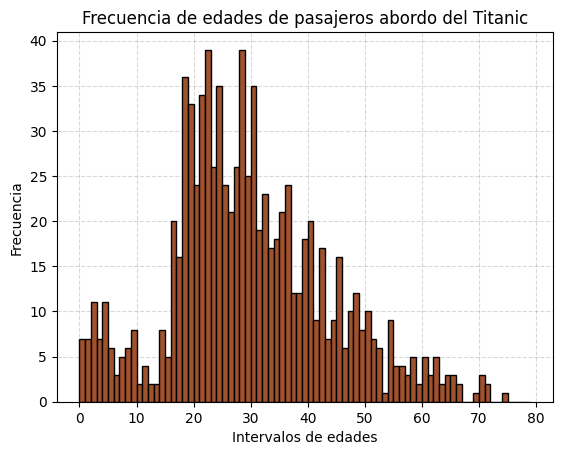

In [10]:
# Supongamos que hacemos un histograma de frecuencias de todas las edades

#Defino mis intervalos
bins = np.arange(0, int(np.max(titanic_sliced['Age'])), 1)

#Grafico
plt.hist(titanic_sliced['Age'],bins = bins,  color = 'sienna',edgecolor="black",zorder=2)
plt.grid(alpha=0.3,color="gray",linestyle="--",zorder=1)
plt.ylabel("Frecuencia")
plt.xlabel("Intervalos de edades")
plt.title("Frecuencia de edades de pasajeros abordo del Titanic")

plt.show()

**Ahora supongamos que lo que queremos ver es cómo las frecuencias están repartidas basándonos en los valores de los percentiles**

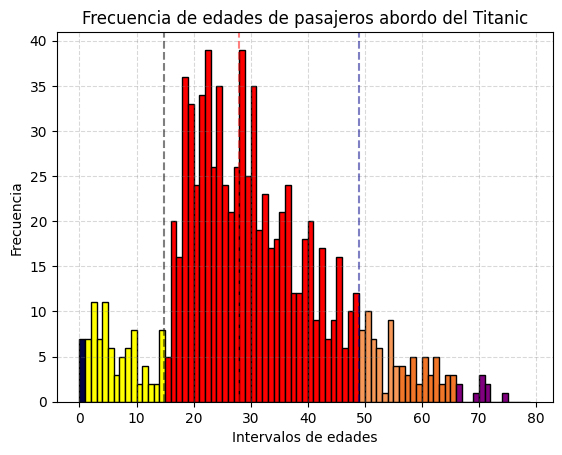

In [11]:

counts, bins, patches = plt.hist( titanic_sliced['Age'], bins = bins,edgecolor="black")

# Colorear las barras según la condición
for patch, left_side, right_side in zip(patches, bins[:-1], bins[1:]):
    bin_center = (left_side + right_side) / 2  # Calcular el centro del bin
    
    #Mayor e igual a 66 (>P99)
    if bin_center >= perc_numpy_age[-1]:
        patch.set_facecolor('purple')
    #Mayor a P95
    elif bin_center > perc_numpy_age[7]:
        patch.set_facecolor('#f17628')
    #Mayor a P90
    elif bin_center > perc_numpy_age[6]:
        patch.set_facecolor('#f79858')
    #Menor a 1
    elif bin_center < perc_numpy_age[0]:
        patch.set_facecolor('#020344')
    #Menor a 5
    elif bin_center < perc_numpy_age[1]:
        patch.set_facecolor('yellow')
    #Menor a 10
    elif bin_center < perc_numpy_age[2]:
        patch.set_facecolor('yellow')
    #Que no cumplan ninguna de las condiciones anteriores
    else:
        patch.set_facecolor('red')
        
plt.grid(alpha=0.3,color="gray",linestyle="--",zorder=1)
plt.ylabel("Frecuencia")
plt.xlabel("Intervalos de edades")
plt.title("Frecuencia de edades de pasajeros abordo del Titanic")

plt.axvline(x = perc_numpy_age[4], color = 'r', linestyle='--', alpha = 0.5) #28
plt.axvline(x = perc_numpy_age[2], color = 'black', linestyle='--', alpha = 0.5) #14.8
plt.axvline(x = perc_numpy_age[-3], color = 'darkblue', linestyle='--', alpha = 0.5) #49
plt.show()

Al observar la distribución con los percentiles (Figura anterior), podemos observar que quizás no se repartan como intuitivamente esperábamos.
De esta manera podemos dividir los datos de manera objetiva.

Vamos a ver otro ejemplo

#### <font color="orange">**Ejemplo 2: DataFrames**

In [12]:
#Cargar los datos

#vamos a volver a ocupar los datos de los precios de la gasolina
ruta='/home/jovyan/Clase/TemasSelectos/data/gas_prices.csv'
gasolina = pd.read_csv(ruta)

#Vamos a hacer una copia del dataframe gasolina 
gasolina_mxn = gasolina.copy() #Usamos .copy() cuando se quiere modificar datos sin alterar el DataFrame original.

#Los precios están en dólares, vamos a convertirlos en pesos méxicanos
gasolina_mxn.iloc[:, 1:] = gasolina.iloc[:, 1:].mul(18).round(2) #.mul(), puedo multiplicar el dataframe por un valor

In [13]:
## Vamos a obtener ahora los percentiles de los precios

perc_gas = np.nanpercentile(gasolina_mxn.iloc[:, 1:], [5, 10, 50, 90, 95]) #np.nanpercentile(), ignora los valores nan
perc_gas

array([ 21.492,  26.604,  60.12 , 100.44 , 110.988])

In [14]:
# Ahora esta es una manera de iluminar sus dataframes. Usos tiene muchos, pero dependerá qué es lo que quieran lograr


# Aquí por facilidad haremos una función que otorgue un color dependiendo de si el valor que evaluamos está por encima, por debajo o 
# en un rango del percentil

def color_fondo(value, column, perc_gas):
    if value <= perc_gas[0]:
        color = 'salmon'
    elif (value > perc_gas[0]) & (value <= perc_gas[1]):
        color = '#49a078'
    elif (value >= perc_gas[4]) & (value < 200):
        color = '#81171b'
    elif (value > perc_gas[3]) & (value <= perc_gas[4]):
        color = '#c75146'
    else:
        color = 'None' #Los deja en blanco
    return f'background-color: {color}'


# Aquí lo que hacemos es cambiar el estilo del dataframe

#Aplicando una función lambda
color_change=lambda x: x.apply(color_fondo, column = x.name, perc_gas = perc_gas)

gasolina_mxn.style.apply(color_change, axis = 0).format(precision=2)
#.to_excel("Df_estilos.xlsx")


,Year,Australia,Canada,France,Germany,Italy,Japan,Mexico,South Korea,UK,USA
0,1990,nan,33.66,65.34,47.70,82.62,56.88,18.00,36.90,50.76,20.88
1,1991,35.28,34.56,62.10,52.20,81.00,62.28,23.40,44.82,54.18,20.52
2,1992,34.02,31.14,64.08,58.86,81.54,64.44,27.00,47.70,55.08,20.34
3,1993,31.14,28.26,61.38,55.26,66.24,74.88,28.08,51.84,51.12,19.98
4,1994,33.12,26.10,64.62,63.36,66.60,78.48,26.64,51.66,53.82,19.98
5,1995,35.10,27.54,76.68,71.28,72.00,79.74,19.98,52.92,57.78,20.70
6,1996,38.16,28.98,79.38,70.92,79.02,65.52,22.50,57.24,60.12,22.14
7,1997,36.90,29.16,72.00,63.54,73.26,58.68,26.46,60.12,68.94,22.14
8,1998,29.34,24.84,69.66,60.12,69.12,50.76,26.82,54.72,73.08,19.08
9,1999,30.96,27.36,69.30,61.56,69.66,58.86,32.22,68.40,77.22,21.06


In [15]:
# Supongamos que queremos analizar un solo país i.e. Mexico

# Calculemos algunos percentiles
mex_q = np.percentile(gasolina_mxn['Mexico'], [20, 50, 80]) 


# Ajustar la función para que sólo adctúe sobre la columna de México

def color_fondo_mx(value, column, perc_gas):
  if column == 'Mexico':
    if value <= perc_gas[0]:
        color = '#216869'
    elif (value > perc_gas[0]) & (value <= perc_gas[1]):
        color = '#49a078'
    elif (value >= perc_gas[2]) :
        color = '#81171b'
    elif (value > perc_gas[1]) & (value <= perc_gas[2]):
        color = '#c75146'
    else:
        color = 'None'
  else:
    color = 'None'
  return f'background-color: {color}'


# Y aquí aplicamos el estilo
(gasolina_mxn.style
 .apply(lambda x: x.apply(color_fondo_mx, column = x.name, perc_gas = mex_q), axis = 0)
 .format(precision=2)
)#.to_excel("Df_estilos.xlsx")

,Year,Australia,Canada,France,Germany,Italy,Japan,Mexico,South Korea,UK,USA
0,1990,nan,33.66,65.34,47.70,82.62,56.88,18.00,36.90,50.76,20.88
1,1991,35.28,34.56,62.10,52.20,81.00,62.28,23.40,44.82,54.18,20.52
2,1992,34.02,31.14,64.08,58.86,81.54,64.44,27.00,47.70,55.08,20.34
3,1993,31.14,28.26,61.38,55.26,66.24,74.88,28.08,51.84,51.12,19.98
4,1994,33.12,26.10,64.62,63.36,66.60,78.48,26.64,51.66,53.82,19.98
5,1995,35.10,27.54,76.68,71.28,72.00,79.74,19.98,52.92,57.78,20.70
6,1996,38.16,28.98,79.38,70.92,79.02,65.52,22.50,57.24,60.12,22.14
7,1997,36.90,29.16,72.00,63.54,73.26,58.68,26.46,60.12,68.94,22.14
8,1998,29.34,24.84,69.66,60.12,69.12,50.76,26.82,54.72,73.08,19.08
9,1999,30.96,27.36,69.30,61.56,69.66,58.86,32.22,68.40,77.22,21.06


------------

### <font color="purple"> **Ejercicio 1**

* Encuentren los percentiles 5, 15, 85 y 95 de 5 países los que ustedes quieran (el percentil debe de ser de cada país no de todos)
* Iluminen el dataframe de tal manera que:
    * Verde claro: por debajo del P5
    * Amarillo: entre el P5 y P15
    * Naranja: entre el P85 y P95
    * Rojo: arriba del P95


In [16]:
#Vamos a elegir USA,UK,GERMANY,FRANCE,CANADA

#Encontrando los percentiles
USA_perc=np.percentile(gasolina_mxn["USA"],[5,15,85,95])
UK_perc=np.percentile(gasolina_mxn["UK"],[5,15,85,95])
Germany_perc=np.percentile(gasolina_mxn["Germany"],[5,15,85,95])
France_perc=np.percentile(gasolina_mxn["France"],[5,15,85,95])
Canada_perc=np.percentile(gasolina_mxn["Canada"],[5,15,85,95])

In [17]:
#Vamos a iluminar el dataframe

#Con esto pinto las columnas de cada país elegido en relación a sus respectivos percentiles
def color_fondo_mx(value, column, paises, perc_gas):
    for ic,c in enumerate(paises):
        if column==c:
  
            if value < perc_gas[ic][0]:
                color = 'green'
            elif (value >= perc_gas[ic][0]) & (value <= perc_gas[ic][1]):
                color = 'yellow'
            elif ((value >= perc_gas[ic][2])&(value<=perc_gas[ic][3])) :
                color = 'orange'
            elif (value > perc_gas[ic][3]):
                color = 'red'
            else:
                color = 'None'
       
            return f'background-color: {color}'

gasolina_mxn.style.apply(lambda x: x.apply(color_fondo_mx, column = x.name, paises=["USA","UK","Germany","France","Canada"], 
                                           perc_gas = [USA_perc,UK_perc, Germany_perc,France_perc,Canada_perc]), axis = 0).format(precision=2)

,Year,Australia,Canada,France,Germany,Italy,Japan,Mexico,South Korea,UK,USA
0,1990,nan,33.66,65.34,47.70,82.62,56.88,18.00,36.90,50.76,20.88
1,1991,35.28,34.56,62.10,52.20,81.00,62.28,23.40,44.82,54.18,20.52
2,1992,34.02,31.14,64.08,58.86,81.54,64.44,27.00,47.70,55.08,20.34
3,1993,31.14,28.26,61.38,55.26,66.24,74.88,28.08,51.84,51.12,19.98
4,1994,33.12,26.10,64.62,63.36,66.60,78.48,26.64,51.66,53.82,19.98
5,1995,35.10,27.54,76.68,71.28,72.00,79.74,19.98,52.92,57.78,20.70
6,1996,38.16,28.98,79.38,70.92,79.02,65.52,22.50,57.24,60.12,22.14
7,1997,36.90,29.16,72.00,63.54,73.26,58.68,26.46,60.12,68.94,22.14
8,1998,29.34,24.84,69.66,60.12,69.12,50.76,26.82,54.72,73.08,19.08
9,1999,30.96,27.36,69.30,61.56,69.66,58.86,32.22,68.40,77.22,21.06


-- ----------------------- --

## <font color="steelblue"> Percentiles en Mapas

Consiste en calcular percentiles en cada punto espacial (grid) y representarlos geográficamente. En este caso, los percentiles se calculan en relación a un periodo base.

In [18]:
# Abrir los datos
ruta="/home/jovyan/Clase/TemasSelectos/data/Temp_1990_2020.nc"
#Vamos a continuar trabajando con los datos de temperatura de australia
#ruta = 'Temp_1990_2020.nc'
ds = xr.open_dataset(ruta)
ds

<xarray.Dataset> Size: 408MB
Dimensions:    (time: 396, latitude: 321, longitude: 401)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1990-01-01 1990-02-01 ... 2022-12-01
  * latitude   (latitude) float32 1kB -8.0 -8.1 -8.2 -8.3 ... -39.8 -39.9 -40.0
  * longitude  (longitude) float32 2kB 110.0 110.1 110.2 ... 149.8 149.9 150.0
Data variables:
    t2m        (time, latitude, longitude) float64 408MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-02 00:45:18 GMT by grib_to_netcdf-2.24.0: /opt/ecmw...

In [19]:
# Seleccionar la variable
tp = ds['t2m']
tp_C = tp-273.15 # convertir los datos a Celcius

In [20]:
# Vamos a seleccionar el periodo base
temp_base = tp_C.where((tp_C.time.dt.year > 1990) & (tp_C.time.dt.year < 2001),drop=True)
temp_base

<xarray.DataArray 't2m' (time: 120, latitude: 321, longitude: 401)> Size: 124MB
array([[[        nan,         nan, 25.83412155, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan, 26.2640278 , ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan, 26.15907138, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * time       (time) datetime64[ns] 960B 1991-01-01 1991-02-01 ... 2000-12-01
  * latitude   (latitude) float32 1kB -8.0 -8.1 -8.2 -8.3 ... -39.8 -39.9 -40.0
  * longitude  (longitude) float32 2kB 110.0 110.1 110.2 ... 149.8 149.9 150.0
Attributes:
    units:      K
    long_name:  2 metre temperature

In [38]:
# Directamente podemos calcular los percentiles

##También podemos obtener percentiles a partir de los quantiles
temp_qt = temp_base.quantile([0.50, 0.95], dim="time",skipna=True) 

P_50 = temp_qt.sel(quantile = 0.50)
P_95 = temp_qt.sel(quantile = 0.95)

/home/jovyan/.local/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [39]:
# Ahora realmente lo interesante de los percentiles es ver si algún año fue anómalo

# Analicemos por ejemplo el 2009
comp_year = tp_C.where((tp_C.time.dt.year == 2009),drop=True)

# Ahora hace que hacer la comparación

result = comp_year.where(comp_year <= P_50,drop=True)
result

<xarray.DataArray 't2m' (time: 11, latitude: 316, longitude: 399)> Size: 11MB
array([[[        nan,         nan, 25.18125701, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[25.88511732, 25.49434736, 24.94347437, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]])
Coordinates:
  * time       (time) datetime64[ns] 88B 2009-01-01 2009-02-01 ... 2009-11-01
  * latitude   (latitude) float32 1kB -8.0 -8.1 -8.2 -8.3 ... -39.8 -39.9 -40.0
  * longitude  (longitude) float32 2kB 110.2 110.3 110.4 ... 149.8 149.9 150.0
    quantile   float64 8B 0.5
Attributes:
    units:      K
    long_name:  2 metre temperature

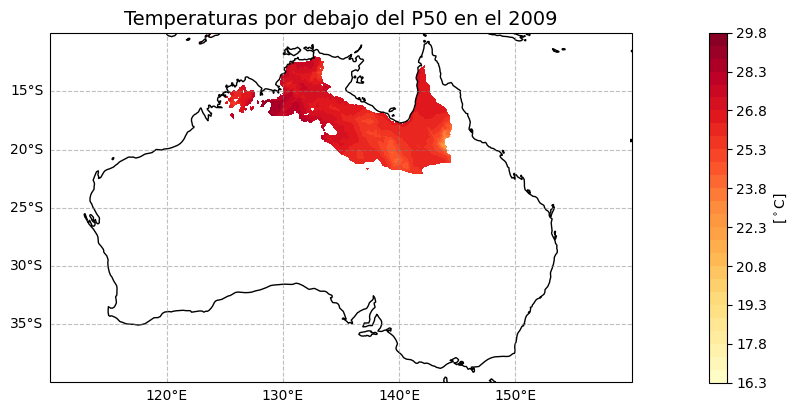

In [40]:
# A diferencia de las anomalías ya no tenemos que hacer más cálculos
# Podemos plotear directamente

fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([110,160, -10, -40], crs=ccrs.PlateCarree())
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
cs = ax.contourf(result.longitude, result.latitude, result[0], levels = np.arange(np.min(result[0]), np.max(result[0]) + 1, 0.5), cmap = 'YlOrRd',  transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '[$^\circ$C]')
plt.title('Temperaturas por debajo del P50 en el 2009', fontsize = 14)
plt.show()

In [41]:
#Ahora vamos a ver las temperaturas por encima del P95
result2 = comp_year.where(comp_year >= P_95,drop=True)

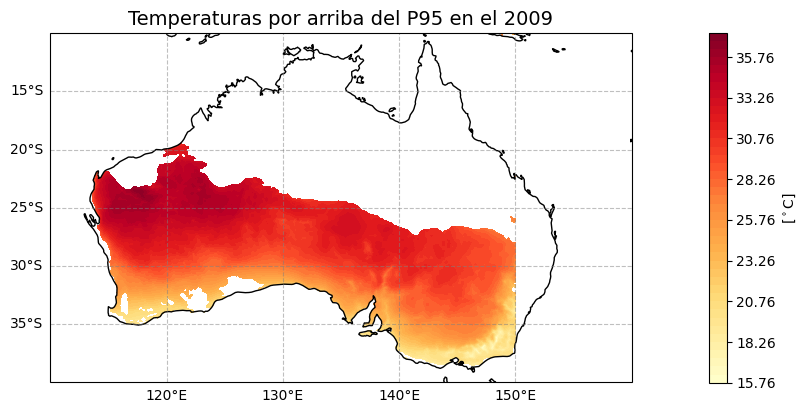

In [42]:
result2 = comp_year.where(comp_year >= P_95)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([110,160, -10, -40], crs=ccrs.PlateCarree())
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
cs = ax.contourf(result2.longitude, result2.latitude, result2[0], levels = np.arange(np.min(result2[0]), np.max(result2[0]) + 1, 0.5), cmap = 'YlOrRd',  transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '[$^\circ$C]')
plt.title('Temperaturas por arriba del P95 en el 2009', fontsize = 14)
plt.show()

### <font color="purple"> **Ejercicio 2** 

Tomando como periodo base de 2010 a 2020, muestra en dónde durante el 2021 se sobrepasa el percentil 99. Explica tus resultados.

In [46]:
# Vamos a seleccionar el periodo base
temp_base_2 = tp_C.where((tp_C.time.dt.year > 2009) & (tp_C.time.dt.year < 2021),drop=True)

#Calculando el percentil 99
temp_99 = temp_base_2.quantile([0.99], dim="time", skipna=True) 

P_99 = temp_99.sel(quantile = 0.99)

/home/jovyan/.local/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [31]:
# Analicemos 2021
comp_year_2 = tp_C.where((tp_C.time.dt.year == 2021),drop=True)

# Ahora hay que hacer la comparación
result_3 = comp_year_2.where(comp_year_2> P_99,drop=True)
result_3

<xarray.DataArray 't2m' (time: 4, latitude: 148, longitude: 201)> Size: 952kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time       (time) datetime64[ns] 32B 2021-01-01 2021-10-01 ... 2021-12-01
  * latitude   (latitude) float32 592B -8.0 -8.1 -8.2 -8.3 ... -22.9 -23.0 -23.1
  * longitude  (longitude) float32 804B 114.9 115.0 115.1 ... 149.8 149.9 150.0
    quantile   float64 8B 0.99
Attributes:
    units:      K
    long_name:  2 metre temperature

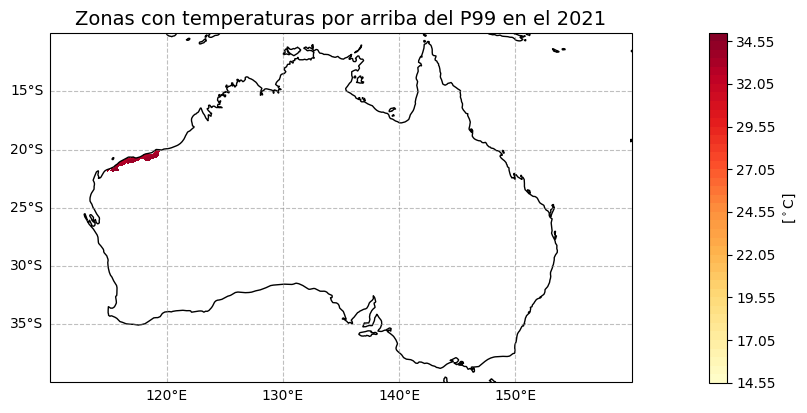

In [44]:
#Graficamos
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([110,160, -10, -40], crs=ccrs.PlateCarree())
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False
cs = ax.contourf(result_3.longitude, result_3.latitude, result_3[0], levels = np.arange(np.min(result_3[0]), np.max(result_3[0]) + 1, 0.5), cmap = 'YlOrRd',  transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '[$^\circ$C]')
plt.title('Zonas con temperaturas por arriba del P99 en el 2021', fontsize = 14)
plt.show()

<font color="brown"> **Interpretación**

Durante el 2021, una pequeña parte del Australía presentó temperaturas extremas en relación al periodo 2010-2020, es decir, las temperaturas en las zonas coloreadas, sobrepasaron el P99 registrado en dicha zona (Este de Australia) durante el 2010-2020.